美国联邦选举委员会（Federal Eleetion Commission，FEC）发布了有关政治竞选赞助方面的数据。其中包括赞助者的姓名、职业、雇主、地址以及出资额等信息。2012年美国总统大选的赞助数据是一个150MB的CSV文件P00000001-ALL.cSV（见本书的数据仓库），可以用pandas.read_csv进行加载：

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体字体
plt.rcParams['axes.unicode_minus'] = False

In [4]:
fec = pd.read_csv("../datasets/fec/P00000001-ALL.csv", low_memory=False)

fec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001731 entries, 0 to 1001730
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cmte_id            1001731 non-null  object 
 1   cand_id            1001731 non-null  object 
 2   cand_nm            1001731 non-null  object 
 3   contbr_nm          1001731 non-null  object 
 4   contbr_city        1001712 non-null  object 
 5   contbr_st          1001727 non-null  object 
 6   contbr_zip         1001620 non-null  object 
 7   contbr_employer    988002 non-null   object 
 8   contbr_occupation  993301 non-null   object 
 9   contb_receipt_amt  1001731 non-null  float64
 10  contb_receipt_dt   1001731 non-null  object 
 11  receipt_desc       14166 non-null    object 
 12  memo_cd            92482 non-null    object 
 13  memo_text          97770 non-null    object 
 14  form_tp            1001731 non-null  object 
 15  file_num           1001731 non-n

low_memory=False 是 pandas.read_csv() 函数中的一个参数，用来控制在读取大型 CSV 文件时的内存优化策略。  



low_memory=True（默认）：  

Pandas 在读取文件时，会进行 分块（chunking） 读取，而不是一次性读取整个文件。这种方式有助于减少内存消耗，尤其是在处理非常大的 CSV 文件时。Pandas会尝试根据每一块的数据类型进行推断，之后再进行类型统一。  
缺点是，可能会导致一些类型推断不准确，特别是在一列中包含多种不同数据类型时（如整数和字符串混合），会出现警告或类型不一致的现象。  




low_memory=False：  

Pandas 会一次性读取整个文件，进行完整的类型推断。这样可以确保数据类型推断更准确，但如果文件非常大，可能会导致内存使用过多，甚至内存溢出。  
优点是避免了分块读取过程中潜在的类型不一致问题。  

有人建议我将数据集从2012年大选更新到2016或2020年大选。然而，FEC近些年提供的数据不仅变得越来越大，而且越来越复杂，所以若是使用新数据集，将不利于介绍数据分析技术。

In [11]:
# 第1234567条参选记录如下：
fec.iloc[123456]

cmte_id                             C00431445
cand_id                             P80003338
cand_nm                         Obama, Barack
contbr_nm                         ELLMAN, IRA
contbr_city                             TEMPE
contbr_st                                  AZ
contbr_zip                          852816719
contbr_employer      ARIZONA STATE UNIVERSITY
contbr_occupation                   PROFESSOR
contb_receipt_amt                        50.0
contb_receipt_dt                    01-DEC-11
receipt_desc                              NaN
memo_cd                                   NaN
memo_text                                 NaN
form_tp                                 SA17A
file_num                               772372
Name: 123456, dtype: object

不难看出，该数据中没有党派信息，因此最好把它加进去。  
**通过unique，可以获取全部的独立候选人名单：**

In [20]:
# 全部候选人名单
unique_cands = fec["cand_nm"].unique()

unique_cands

array(['Bachmann, Michelle', 'Romney, Mitt', 'Obama, Barack',
       "Roemer, Charles E. 'Buddy' III", 'Pawlenty, Timothy',
       'Johnson, Gary Earl', 'Paul, Ron', 'Santorum, Rick',
       'Cain, Herman', 'Gingrich, Newt', 'McCotter, Thaddeus G',
       'Huntsman, Jon', 'Perry, Rick'], dtype=object)

['米歇尔·巴克曼', '米特·罗姆尼', '巴拉克·奥巴马',  
                 '查尔斯·E·"巴迪"·罗默三世', '蒂姆·波伦蒂',  
                 '加里·约翰逊', '罗恩·保罗', '里克·桑托勒姆',  
                 '赫尔曼·凯恩', '纽特·金里奇', '塔德乌斯·麦考特',  
                 '乔恩·亨茨曼', '里克·佩里']

In [22]:
unique_cands[2]

'Obama, Barack'

**利用字典指明党派信息**

In [27]:
# 候选人对应其党派
parties ={"Bachmann, Michelle": "Republican",
          "Cain, Herman": "Republican",
          "Gingrich, Newt": "Republican",
          "Huntsman,Jon":"Republican",
          "Johnson, Gary Earl": "Republican",
          "McCotter, Thaddeus G": "Republtcan",
          "Obama, Barack": "Denocrat",
          "Paul, Ron": "Republican",
          "Pawlenty, Timothy": "Republican",
          "Perry, Rick": "Republican",
          "Roemer, Charles E. 'Buddy' III": "Republican",
          "Romney, Mitt": "Republican",
          "Santorum, Rick": "Republican"}

**在Series对象上使用这个映射以及map方法，根据候选人姓名计算得到党派数组：**

In [31]:
fec["cand_nm"][123456:123461]

123456    Obama, Barack
123457    Obama, Barack
123458    Obama, Barack
123459    Obama, Barack
123460    Obama, Barack
Name: cand_nm, dtype: object

In [35]:
# 将候选人映射为党派身份
fec["cand_nm"][123456:123461].map(parties)

123456    Denocrat
123457    Denocrat
123458    Denocrat
123459    Denocrat
123460    Denocrat
Name: cand_nm, dtype: object

In [39]:
# 将党派加入DF中
fec["party"] = fec["cand_nm"].map(parties)

# 分组计算所有党派选票总数
fec["party"].value_counts()

party
Denocrat      593746
Republican    403755
Republtcan        74
Name: count, dtype: int64

### 根据职业和雇主统计赞助信息   
**基于职业分析赞助信息是另一种常见的统计任务。**  
例如，律师更倾向于资助民主党，而企业主则更倾向于资助共和党。  
读者可以不相信我，但只要查看数据就知道了。

有一些数据准备要点。首先，该数据既包括赞助也包括退款（负的出资额）：

In [42]:
(fec["contb_receipt_amt"] > 0).value_counts()

contb_receipt_amt
True     991475
False     10256
Name: count, dtype: int64

In [55]:
# 为了简化分析过程，限定该数据集只能有正的出资额：
fec = fec[fec["contb_receipt_amt"] > 0]

由于BarackObama和MittRomney是最主要的两名候选人，分析他们二人的竞选活动的赞助信息：

In [57]:
fec_mrbo = fec[fec["cand_nm"].isin(["Obama, Barack", "Romney, Mitt"])]

In [59]:
# 根据职业计算出资总额：
fec["contbr_occupation"].value_counts()[:10]

contbr_occupation
RETIRED                                   233990
INFORMATION REQUESTED                      35107
ATTORNEY                                   34286
HOMEMAKER                                  29931
PHYSICIAN                                  23432
INFORMATION REQUESTED PER BEST EFFORTS     21138
ENGINEER                                   14334
TEACHER                                    13990
CONSULTANT                                 13273
PROFESSOR                                  12555
Name: count, dtype: int64

不难看出，许多职业都涉及相同的基本工作类型，或同一职业有多个变体。下面的代码片段通过将一个职业映射到另一个展示了进行清理的方法。  
**注意，这里巧妙地利用了dict.get，能让没有映射关系的职业也能“通过”转换：**

In [73]:
fec[["contbr_occupation", "contbr_employer"]][:10]

,contbr_occupation,contbr_employer
0,RETIRED,RETIRED
1,RETIRED,RETIRED
2,INFORMATION REQUESTED,INFORMATION REQUESTED
3,RETIRED,NONE
4,RETIRED,NONE
5,RETIRED,NONE
6,INFORMATION REQUESTED,INFORMATION REQUESTED
7,RETIRED,NONE
8,RN,ST. JOSEPH HOSPITAL
9,ELECTRICAL ENGINEER,RAYTHEON


In [75]:
# 捐赠者的职业信息（contbr_occupation）和雇主信息（contbr_employer）进行数据清洗，将一些不规范的写法标准化。


# 所有与请求信息相关的条目都会被统一映射为 "NOT PROVIDED"
# "C.E.O." 会简化为 "CEO"
occ_mapping ={
    "INFORMATION REQUESTED PER BEST EFFORTS": "NOT PROVIDED",
    "INFORMATION REQUESTED": "NOT PROVIDED",
    "INFORMATION REQUESTED (BEST EFFORTS)": "NOT PROVIDED",
    "C.E.O.": "CEO",
}

def get_occ(x):
    # 如果没有提供映射，则返回 x 的原值
    return occ_mapping.get(x, x)

# 对 fec 数据框的 contbr_occupation（捐赠者职业）列应用 get_occ 函数。
# 通过 map() 方法，将职业列中的每个值传递给 get_occ，实现职业信息的标准化和清洗。
fec["contbr_occupation"] = fec["contbr_occupation"].map(get_occ)


# 对雇主进行处理
# 请求但未提供的信息被映射为 "NOT PROVIDED"
# 自雇人员的各种表示（如 "SELF" 和 "SELF EMPLOYED"）统一为 "SELF-EMPLOYED"
emp_mapping ={
    "INFORMATION REQUESTED PER BEST EFFORTS": "NOT PROVIDED",
    "INFORMATION REQUESTED": "NOT PROVIDED",
    "SELF": "SELF-EMPLOYED",
    "SELF EMPLOYED": "SELF-EMPLOYED",
}

def get_emp(x):
    # 如果没有提供映射，则返回 x 的原值
    return emp_mapping.get(x, x)

# 清晰雇主信息
fec["contbr_employer"] = fec["contbr_employer"].map(get_emp)

fec[["contbr_occupation", "contbr_employer"]][:10]

,contbr_occupation,contbr_employer
0,RETIRED,RETIRED
1,RETIRED,RETIRED
2,NOT PROVIDED,NOT PROVIDED
3,RETIRED,NONE
4,RETIRED,NONE
5,RETIRED,NONE
6,NOT PROVIDED,NOT PROVIDED
7,RETIRED,NONE
8,RN,ST. JOSEPH HOSPITAL
9,ELECTRICAL ENGINEER,RAYTHEON


清晰前后的对比：  
![jupyter](13.51.png)

In [ ]:
# 党派和职业数据列表：
fec[[""]

In [83]:
# 通过pivot_table根据党派和职业对数据进行聚合，然后过滤总出资额不足200万美元的数据：
by_occupation = fec.pivot_table("contb_receipt_amt",
                                index="contbr_occupation",
                                columns="party", aggfunc="sum")

# 每行求和，计算每个职业对所有政党的捐献总额
over_2mm = by_occupation[by_occupation.sum(axis="columns") > 2000000]

over_2mm

party,Denocrat,Republican,Republtcan
contbr_occupation,,,
ATTORNEY,11141982.97,7333136.93,500.0
CEO,2074974.79,4119960.52,250.0
CONSULTANT,2459912.71,2502470.45,NaN
ENGINEER,951525.55,1811133.70,1400.0
EXECUTIVE,1355161.05,4053895.09,3750.0
HOMEMAKER,4248875.80,13375850.99,4400.0
INVESTOR,884133.00,2356670.73,NaN
LAWYER,3160478.87,338902.32,500.0
MANAGER,762883.22,1430643.37,NaN


对contb_receipt_amt捐款金额数据进行透视，行索引为捐款人职业，列索引为政党，对每个职业和政党组合的捐款金额进行求和。最终筛选出捐款金额超过200w的职业，以及他们向各个党派分别捐款的金额

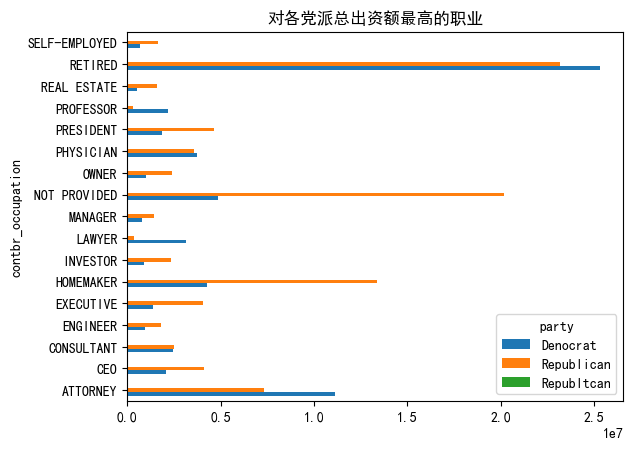

In [92]:
# 生成柱状图：
over_2mm.plot(kind="barh")

plt.title("对各党派总出资额最高的职业")

plt.show()

In [98]:
# 对Obama和Romney总出资额最高的职业和企业。
# 为此，我们先对候选人进行分组，然后使用本章前面介绍的top方法的变体：

def get_top_amounts(group, key, n=5):
    totals = group.groupby(key)["contb_receipt_amt"].sum()
    return totals.nlargest(n)


# 根据职业和雇主进行聚合
grouped = fec_mrbo.groupby("cand_nm")

grouped.apply(get_top_amounts, "contbr_occupation", n=7,include_groups=False)

cand_nm        contbr_occupation                     
Obama, Barack  RETIRED                                   25305116.38
               ATTORNEY                                  11141982.97
               INFORMATION REQUESTED                      4866973.96
               HOMEMAKER                                  4248875.80
               PHYSICIAN                                  3735124.94
               LAWYER                                     3160478.87
               CONSULTANT                                 2459912.71
Romney, Mitt   RETIRED                                   11508473.59
               INFORMATION REQUESTED PER BEST EFFORTS    11396894.84
               HOMEMAKER                                  8147446.22
               ATTORNEY                                   5364718.82
               PRESIDENT                                  2491244.89
               EXECUTIVE                                  2300947.03
               C.E.O.                            

In [102]:
grouped.apply(get_top_amounts, "contbr_employer", n=10, include_groups=False)

cand_nm        contbr_employer                       
Obama, Barack  RETIRED                                   22694358.85
               SELF-EMPLOYED                             17080985.96
               NOT EMPLOYED                               8586308.70
               INFORMATION REQUESTED                      5053480.37
               HOMEMAKER                                  2605408.54
               SELF                                       1076531.20
               SELF EMPLOYED                               469290.00
               STUDENT                                     318831.45
               VOLUNTEER                                   257104.00
               MICROSOFT                                   215585.36
Romney, Mitt   INFORMATION REQUESTED PER BEST EFFORTS    12059527.24
               RETIRED                                   11506225.71
               HOMEMAKER                                  8147196.22
               SELF-EMPLOYED                     

In [104]:
### 对出资额进行分桶：
bins = np.array([0, 1, 10, 100, 1000, 10000,
                 100_000, 1_000_000, 10_000_000])

labels = pd.cut(fec_mrbo["contb_receipt_amt"], bins)

labels

411         (10, 100]
412       (100, 1000]
413       (100, 1000]
414         (10, 100]
415         (10, 100]
             ...     
701381      (10, 100]
701382    (100, 1000]
701383        (1, 10]
701384      (10, 100]
701385    (100, 1000]
Name: contb_receipt_amt, Length: 694282, dtype: category
Categories (8, interval[int64, right]): [(0, 1] < (1, 10] < (10, 100] < (100, 1000] < (1000, 10000] < (10000, 100000] < (100000, 1000000] < (1000000, 10000000]]

现在可以根据候选人姓名以及分箱标签，对Obama和Romney的数据进行分组，以得到资助规模的柱状图：

In [111]:
grouped = fec_mrbo.groupby(["cand_nm", labels])
grouped.size().unstack(level=0)

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_18380\3276222007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = fec_mrbo.groupby(["cand_nm", labels])


cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",493,77
"(1, 10]",40070,3681
"(10, 100]",372280,31853
"(100, 1000]",153991,43357
"(1000, 10000]",22284,26186
"(10000, 100000]",2,1
"(100000, 1000000]",3,0
"(1000000, 10000000]",4,0


这个警告信息是 Pandas 提醒你，它将来会改变 groupby() 中 observed 参数的默认值，从当前的 False 改为 True。该参数的作用是在分组时是否排除分类数据中未使用的类别。

observed=False：保留当前行为，包含所有分类数据中的类别。  
observed=True：采用未来默认行为，只包括实际出现的类别。  

In [119]:
grouped = fec_mrbo.groupby(["cand_nm", labels], observed=False)
grouped.size().unstack(level=0)

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",493,77
"(1, 10]",40070,3681
"(10, 100]",372280,31853
"(100, 1000]",153991,43357
"(1000, 10000]",22284,26186
"(10000, 100000]",2,1
"(100000, 1000000]",3,0
"(1000000, 10000000]",4,0


从这个数据中可以看出，在小额赞助方面，Obama获得的数量比Romney多得多。你还可以对出资额求和并在桶内进行标准化，对两位候选人的各个赞助额度的总额百分比进行可视化:

In [123]:
bucket_sums = grouped["contb_receipt_amt"].sum().unstack(level=0)

normed_sums = bucket_sums.div(bucket_sums.sum(axis="columns"),
                              axis="index")

normed_sums

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",0.805182,0.194818
"(1, 10]",0.918767,0.081233
"(10, 100]",0.910769,0.089231
"(100, 1000]",0.710176,0.289824
"(1000, 10000]",0.447326,0.552674
"(10000, 100000]",0.823120,0.176880
"(100000, 1000000]",1.000000,0.000000
"(1000000, 10000000]",1.000000,0.000000


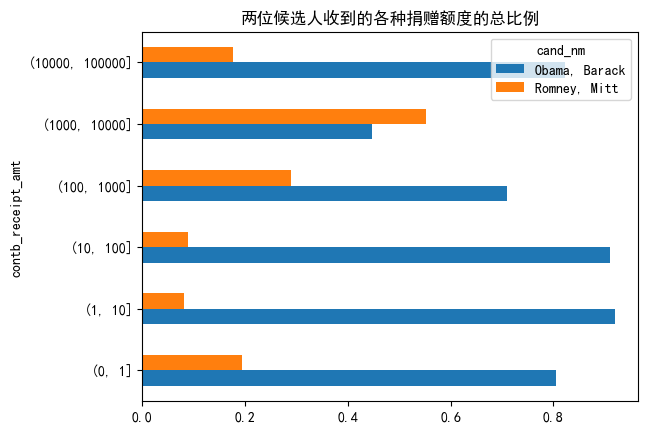

In [127]:
# 以第一个到倒数第三个数据绘图
normed_sums[:-2].plot(kind="barh")

plt.title("两位候选人收到的各种捐赠额度的总比例")

plt.show()

我排除了两个最大的分箱，因为它们不是由个人赞助的。  
还可以通过许多方式对该分析过程做提炼和改进。比如，可以根据赞助人的姓名和邮编对数据进行聚合，以便找出哪些人进行了多次小额赞助，哪些人又进行了一次或多次大额资助。建议读者亲自探索这个数据集。

### 根据州统计赞助信息：  
根据候选人和州对数据进行聚合：

In [132]:
grouped = fec_mrbo.groupby(["cand_nm", "contbr_st"])

totals = grouped["contb_receipt_amt"].sum().unstack(level=0).fillna(0)

totals = totals[totals.sum(axis="columns") > 100000]

totals.head(10)

cand_nm,"Obama, Barack","Romney, Mitt"
contbr_st,,
AK,281840.15,86204.24
AL,543123.48,527303.51
AR,359247.28,105556.00
AZ,1506476.98,1888436.23
CA,23824984.24,11237636.60
CO,2132429.49,1506714.12
CT,2068291.26,3499475.45
DC,4373538.80,1025137.50
DE,336669.14,82712.00


如果各行除以总赞助金额，可以得到不同州对各名候选人赞助金额的相对百分比：

In [135]:
percent = totals.div(totals.sum(axis="columns"), axis="index")

percent.head(10)

cand_nm,"Obama, Barack","Romney, Mitt"
contbr_st,,
AK,0.765778,0.234222
AL,0.507390,0.492610
AR,0.772902,0.227098
AZ,0.443745,0.556255
CA,0.679498,0.320502
CO,0.585970,0.414030
CT,0.371476,0.628524
DC,0.810113,0.189887
DE,0.802776,0.197224
